In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Sample data
data = pd.DataFrame({'Profit': [200, 500, 1000, 1500, 3000]})

# Initialize scaler
scaler = MinMaxScaler()

# Apply normalization
data['Profit_Normalized'] = scaler.fit_transform(data[['Profit']])

print(data)

   Profit  Profit_Normalized
0     200           0.000000
1     500           0.107143
2    1000           0.285714
3    1500           0.464286
4    3000           1.000000


In [2]:
import numpy as np

# Sample data
data = pd.DataFrame({'Sales': [10, 50, 200, 1000, 5000]})

# Apply log transformation
data['Sales_Log'] = np.log(data['Sales'])

print(data)

   Sales  Sales_Log
0     10   2.302585
1     50   3.912023
2    200   5.298317
3   1000   6.907755
4   5000   8.517193


In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df=pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [10]:
df.shape


(1000, 3)

In [3]:
df.sample(5)


,cgpa,placement_exam_marks,placed
683,6.50,69.0,0
973,6.10,37.0,1
628,7.12,9.0,0
11,6.38,7.0,1
141,7.19,18.0,0


C:\Users\admin\AppData\Local\Temp\ipykernel_9900\49520821.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\admin\AppData\Local\Temp\ipykernel_9900\49520821.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


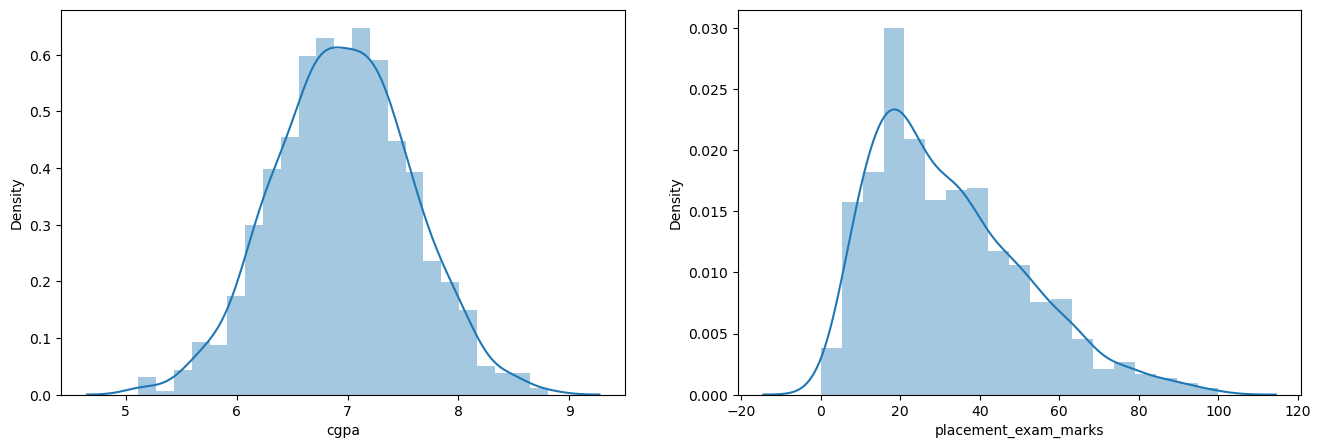

In [28]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()


In [3]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())


Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [4]:
# Finding the boundary values
print("Highest allowed",df['cgpa'].mean() 
      + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 
      3*df['cgpa'].std())


Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [5]:
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]


,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [8]:
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df


,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [11]:
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std() #calculating z score


In [12]:
df[df['cgpa_zscore'] > 3]


,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [13]:
df[df['cgpa_zscore'] < -3]


,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [15]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]


,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [16]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & 
(df['cgpa_zscore'] > -3)]

In [18]:
new_df.shape

(995, 4)

In [19]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()


In [21]:
lower_limit

np.float64(5.113546374602832)

In [24]:
upper_limit

np.float64(8.808933625397168)

In [25]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)


In [23]:
 df['cgpa']<lower_limit

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997     True
998    False
999     True
Name: cgpa, Length: 1000, dtype: bool

In [22]:
 df['cgpa']>upper_limit

0      False
1      False
2      False
3      False
4      False
       ...  
995     True
996     True
997    False
998    False
999    False
Name: cgpa, Length: 1000, dtype: bool

In [26]:
df.shape

(1000, 4)

In [27]:
df['cgpa'].describe()


count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_9900\49520821.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\admin\AppData\Local\Temp\ipykernel_9900\49520821.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


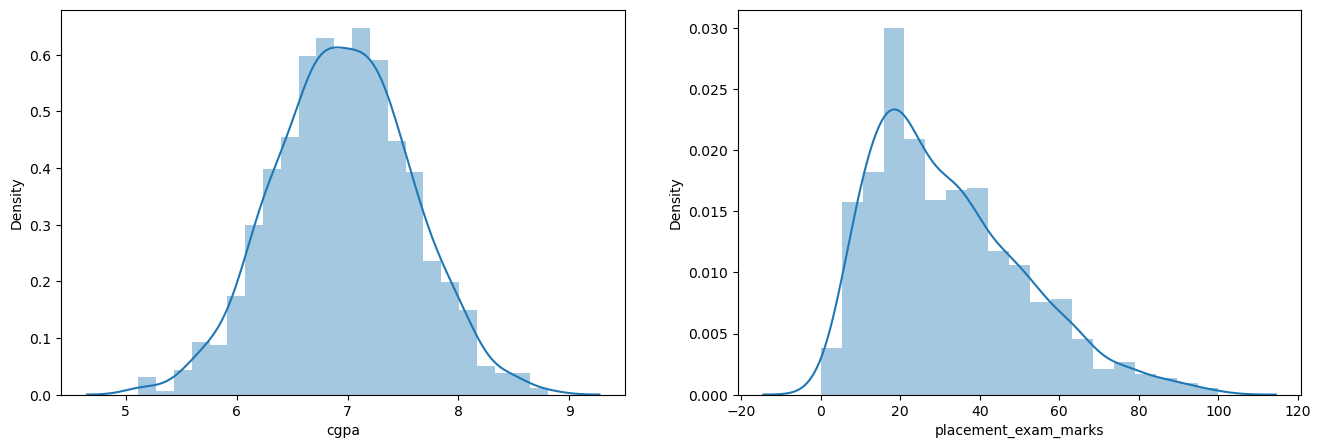

In [29]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()


In [40]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

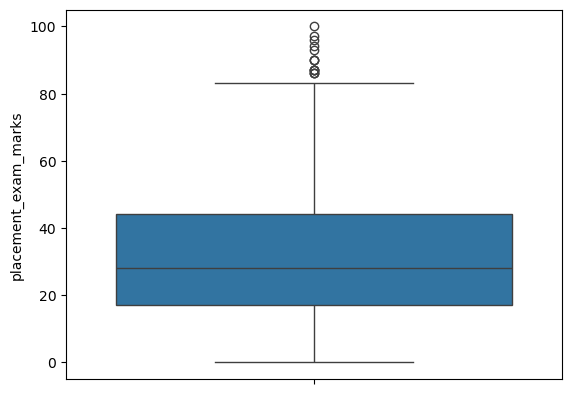

In [32]:
sns.boxplot(df['placement_exam_marks'])

In [33]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [34]:
iqr = percentile75 - percentile25

In [35]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [36]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


In [37]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed,cgpa_zscore
9,7.75,94.0,1,1.280667
40,6.60,86.0,1,-0.586526
61,7.51,86.0,0,0.890992
134,6.33,93.0,0,-1.024910
162,7.80,90.0,0,1.361849
283,7.09,87.0,0,0.209061
290,8.38,87.0,0,2.303564
311,6.97,87.0,1,0.014223
324,6.64,90.0,0,-0.521580
630,6.56,96.0,1,-0.651472


In [39]:
new_df = df[df['placement_exam_marks'] < upper_limit]
new_df.shape

(985, 4)

C:\Users\admin\AppData\Local\Temp\ipykernel_9900\3798459719.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\admin\AppData\Local\Temp\ipykernel_9900\3798459719.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


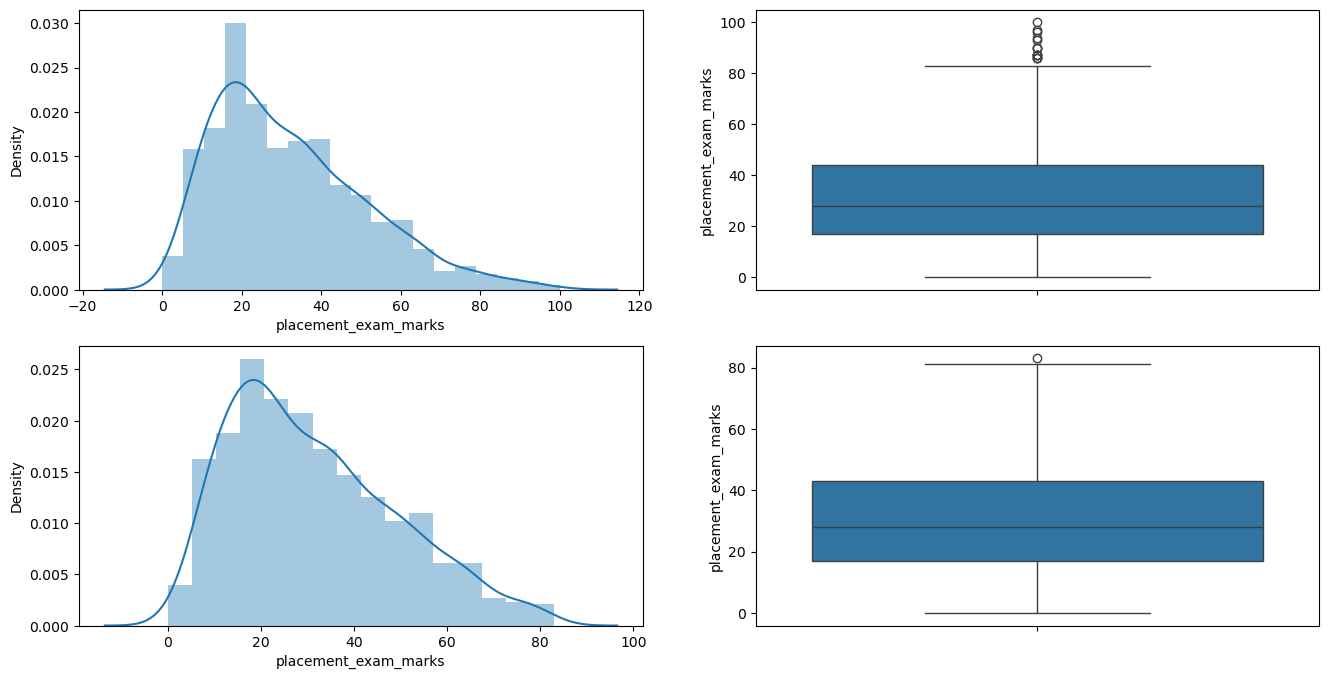

In [45]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

In [43]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [44]:
new_df_cap.shape

(1000, 4)

C:\Users\admin\AppData\Local\Temp\ipykernel_9900\2127205041.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\admin\AppData\Local\Temp\ipykernel_9900\2127205041.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])


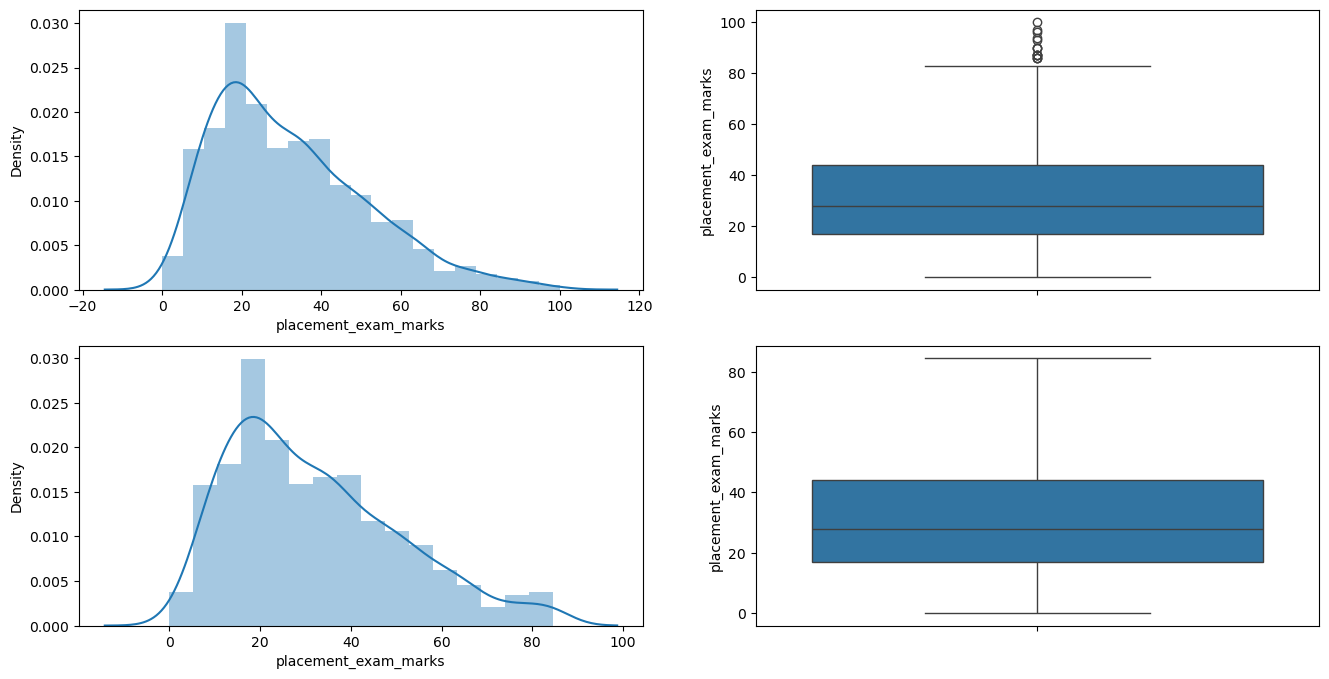

In [46]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()

In [33]:
df = pd.read_csv('weight-height.csv')

In [34]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [35]:
df.shape

(10000, 3)

In [36]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_12024\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

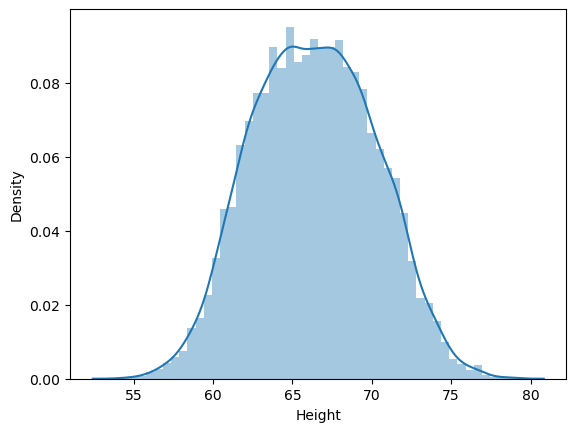

In [37]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

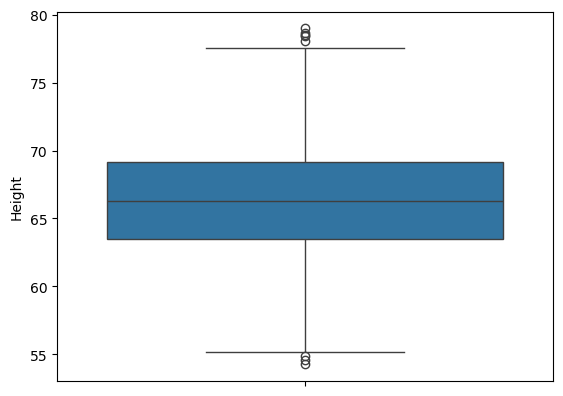

In [38]:
sns.boxplot(df['Height'])

In [39]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [40]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [41]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [42]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_12024\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

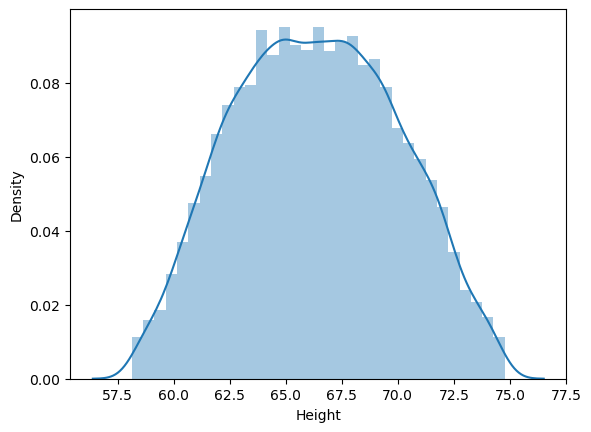

In [43]:
sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

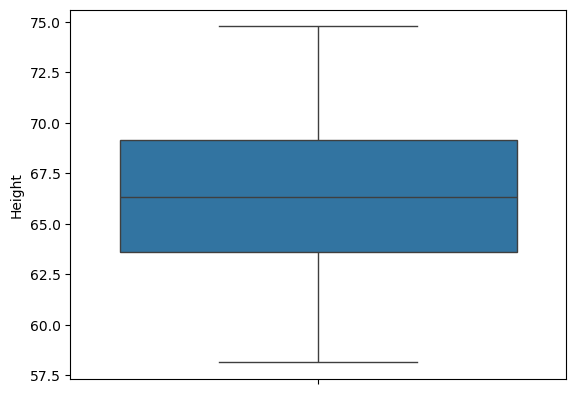

In [44]:
sns.boxplot(new_df['Height'])

In [ ]:
# Capping --> Winsorization

In [45]:
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [46]:
df.shape

(10000, 3)

In [47]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_17052\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

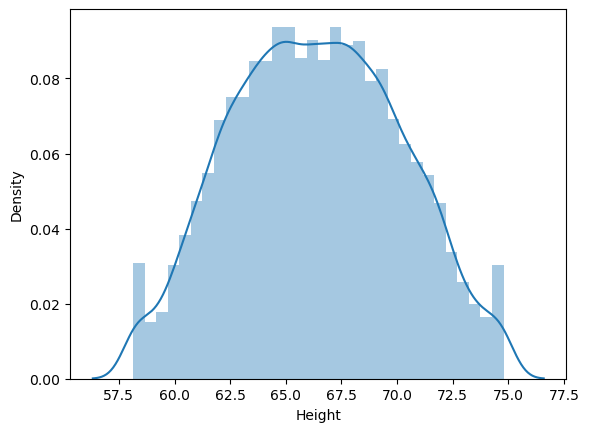

In [58]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

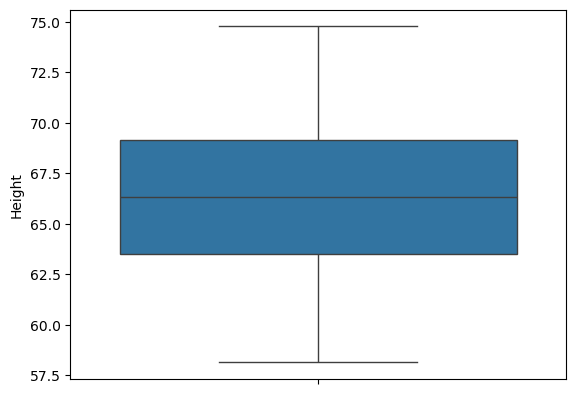

In [48]:
sns.boxplot(df['Height'])

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
df=pd.read_csv("loan_approved.csv")

In [2]:
df['Married'].value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

In [3]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [4]:
df_encoded = pd.get_dummies(df, columns=['Married'], prefix='Married')

In [5]:
df_encoded.columns

Index(['Loan_ID', 'Gender', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)', 'Married_No', 'Married_Yes'],
      dtype='object')

In [7]:
df_encoded

,Loan_ID,Gender,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),Married_No,Married_Yes
0,LP001002,Male,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,True,False
1,LP001003,Male,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,False,True
2,LP001005,Male,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,False,True
3,LP001006,Male,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,False,True
4,LP001008,Male,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,True,False
610,LP002979,Male,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,False,True
611,LP002983,Male,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,False,True
612,LP002984,Male,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,False,True


In [8]:
df.Education.value_counts()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [9]:
Education_enc=OrdinalEncoder(categories=[['Graduate', 'Not Graduate']])

In [10]:
df['Education'] = Education_enc.fit_transform(df[['Education']])

In [11]:
df.Education.value_counts()

Education
0.0    480
1.0    134
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Loan_Status (Approved)'] = encoder.fit_transform(df['Loan_Status (Approved)'])

In [13]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,0.0,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,0.0,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,0.0,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,1.0,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,0.0,No,6000,0.0,141.0,360.0,1.0,Urban,1
